<a href="https://colab.research.google.com/github/eliza-aurora-carling/Admin/blob/main/Arrhythmia_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HEALTHY VALIDATION: Two g_CaL Conditions

g_CaL = 0.172: APD90 = 19.7 ms, EAD = False
  Max V = 2717.3 mV

g_CaL = 0.278: APD90 = 12.8 ms, EAD = False
  Max V = 2229.1 mV


/tmp/ipykernel_15592/3687447810.py:55: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp((V - self.theta_d) / self.sigma_d))
/tmp/ipykernel_15592/3687447810.py:61: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp((V - self.theta_x) / self.sigma_x))


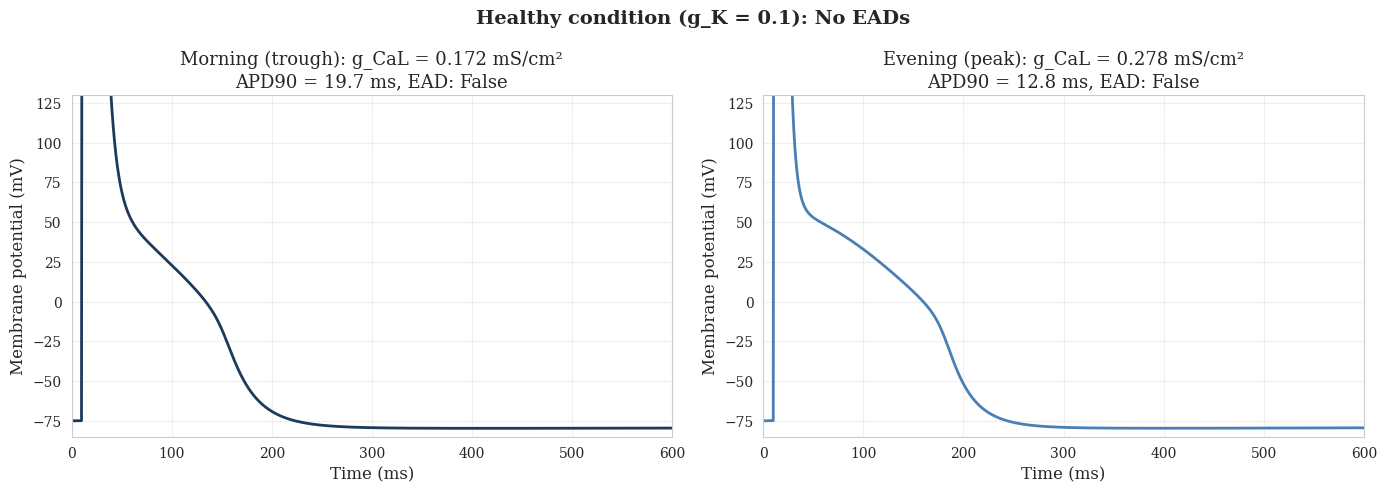


Figure saved: healthy_validation_two_panels.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import seaborn as sns

# Set seaborn style
sns.set_style("whitegrid")

# Times New Roman font
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif', 'Liberation Serif', 'serif'],
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.figsize': (14, 5)
})

# Colours
COLORS = ['#0C1A2B', '#1B3A5C', '#2E5A88', '#4A7FB5', '#7BA3CC']


class SimpleCircadianModel:
    """Simplified model for healthy action potentials only."""

    def __init__(self):
        # Membrane capacitance
        self.C = 1.0  # µF/cm²

        # Potassium current parameters
        self.g_K = 0.1  # mS/cm² (healthy)
        self.E_K = -80  # mV

        # Calcium current parameters
        self.E_Ca = 60  # mV
        self.theta_d = -7.3  # mV
        self.sigma_d = -8.6  # mV
        self.theta_f = -13.3  # mV
        self.sigma_f = 11.9  # mV
        self.tau_f = 80  # ms

        # Potassium gating
        self.theta_x = -40  # mV
        self.sigma_x = -5  # mV
        self.tau_x = 300  # ms

        # Stimulus - INCREASED to ensure AP fires
        self.stim_start = 10  # ms
        self.stim_duration = 5  # ms
        self.stim_amplitude = 800  # µA/cm²

    def d_inf(self, V):
        return 1.0 / (1.0 + np.exp((V - self.theta_d) / self.sigma_d))

    def f_inf(self, V):
        return 1.0 / (1.0 + np.exp((V - self.theta_f) / self.sigma_f))

    def x_inf(self, V):
        return 1.0 / (1.0 + np.exp((V - self.theta_x) / self.sigma_x))

    def I_stim(self, t):
        if self.stim_start <= t <= self.stim_start + self.stim_duration:
            return self.stim_amplitude
        return 0

    def system(self, t, y, g_CaL):
        V, f, x = y
        I_CaL = g_CaL * self.d_inf(V) * f * (V - self.E_Ca)
        I_K = self.g_K * x * (V - self.E_K)
        I_app = self.I_stim(t)

        dV_dt = (I_app - I_CaL - I_K) / self.C
        df_dt = (self.f_inf(V) - f) / self.tau_f
        dx_dt = (self.x_inf(V) - x) / self.tau_x

        return [dV_dt, df_dt, dx_dt]

    def simulate(self, g_CaL, duration=600):
        # Initial conditions - more excitable
        V0 = -75
        f0 = 1.0
        x0 = 0.0

        t_eval = np.linspace(0, duration, 5000)
        solution = solve_ivp(
            lambda t, y: self.system(t, y, g_CaL),
            (0, duration), [V0, f0, x0],
            method='RK45', t_eval=t_eval,
            rtol=1e-6, atol=1e-8
        )

        return solution.t, solution.y[0]  # Return time and voltage


def calculate_apd90(V, t):
    """Calculate APD90 from voltage trace."""
    peak_idx = np.argmax(V)
    V_peak = V[peak_idx]
    V_rest = np.min(V[-100:])
    V_target = V_peak - 0.9 * (V_peak - V_rest)

    for i in range(peak_idx, len(V)):
        if V[i] <= V_target:
            return t[i] - t[peak_idx]
    return np.nan


def detect_ead(V, t, threshold=-20, min_peak_distance=50):
    """Detect early afterdepolarisations."""
    from scipy.signal import find_peaks
    peak_idx = np.argmax(V)
    V_repol = V[peak_idx:]
    if len(V_repol) < min_peak_distance:
        return False
    peaks, _ = find_peaks(V_repol, height=threshold, distance=min_peak_distance)
    return len(peaks) > 1


# Run simulation
print("=" * 60)
print("HEALTHY VALIDATION: Two g_CaL Conditions")
print("=" * 60)

model = SimpleCircadianModel()

# The two g_CaL values from your code
g_CaL_values = [0.172, 0.278]
labels = ['Morning (trough)', 'Evening (peak)']
colors = [COLORS[1], COLORS[3]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, g_CaL, label, color in zip(axes, g_CaL_values, labels, colors):
    t, V = model.simulate(g_CaL, duration=600)

    apd90 = calculate_apd90(V, t)
    ead = detect_ead(V, t)

    ax.plot(t, V, color=color, linewidth=2)
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Membrane potential (mV)')
    ax.set_title(f'{label}: g_CaL = {g_CaL:.3f} mS/cm²\nAPD90 = {apd90:.1f} ms, EAD: {ead}')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 600)
    ax.set_ylim(-85, 130)

    print(f"\ng_CaL = {g_CaL:.3f}: APD90 = {apd90:.1f} ms, EAD = {ead}")
    print(f"  Max V = {np.max(V):.1f} mV")

plt.suptitle('Healthy condition (g_K = 0.1): No EADs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('healthy_validation_two_panels.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 60)
print("Figure saved: healthy_validation_two_panels.png")
print("=" * 60)


♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ 
CIRCADIAN ARRHYTHMIA MODEL
Time-of-day dependence of arrhythmic risk
Based on Diekman & Wei (2021), Biophysical Journal
♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ 
FIGURE 1: Risk of EADs increases with reduced g_K (morning)


/tmp/ipykernel_15592/3798000885.py:65: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp((V - self.theta_d) / self.sigma_d))
/tmp/ipykernel_15592/3798000885.py:71: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp((V - self.theta_x) / self.sigma_x))



Healthy (g_K = 0.1):
  g_CaL = 0.172 mS/cm²
  APD90 = 19.7 ms
  EAD detected: False
  Max V = 2700.6 mV

Moderate impairment (g_K = 0.05):
  g_CaL = 0.172 mS/cm²
  APD90 = 20.2 ms
  EAD detected: False
  Max V = 2704.0 mV

Severe impairment (g_K = 0.025):
  g_CaL = 0.172 mS/cm²
  APD90 = 17.4 ms
  EAD detected: True
  Max V = 2705.6 mV


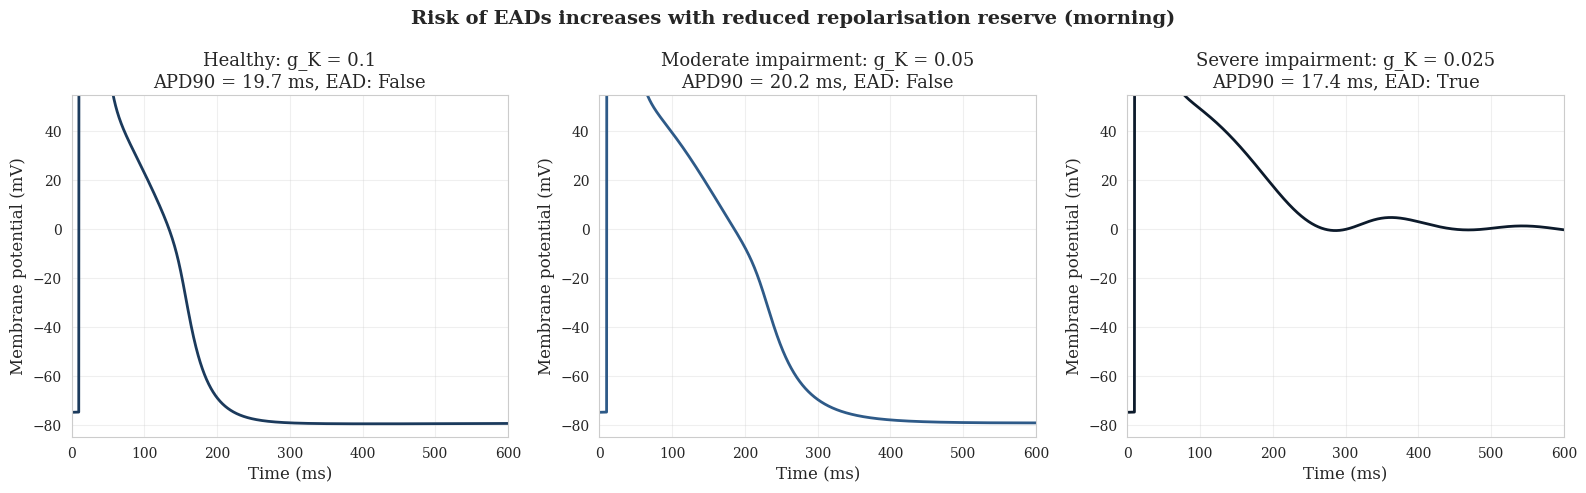


FIGURE 2: Time-of-day dependence of arrhythmic risk

Healthy (g_K = 0.1), Morning (hour 3):
  g_CaL = 0.172 mS/cm²
  APD90 = 19.7 ms
  EAD detected: False

Healthy (g_K = 0.1), Evening (hour 15):
  g_CaL = 0.278 mS/cm²
  APD90 = 13.0 ms
  EAD detected: False

Moderate impairment (g_K = 0.05), Morning (hour 3):
  g_CaL = 0.172 mS/cm²
  APD90 = 20.2 ms
  EAD detected: False

Moderate impairment (g_K = 0.05), Evening (hour 15):
  g_CaL = 0.278 mS/cm²
  APD90 = 13.1 ms
  EAD detected: False

Severe impairment (g_K = 0.025), Morning (hour 3):
  g_CaL = 0.172 mS/cm²
  APD90 = 17.4 ms
  EAD detected: True

Severe impairment (g_K = 0.025), Evening (hour 15):
  g_CaL = 0.278 mS/cm²
  APD90 = 10.4 ms
  EAD detected: False


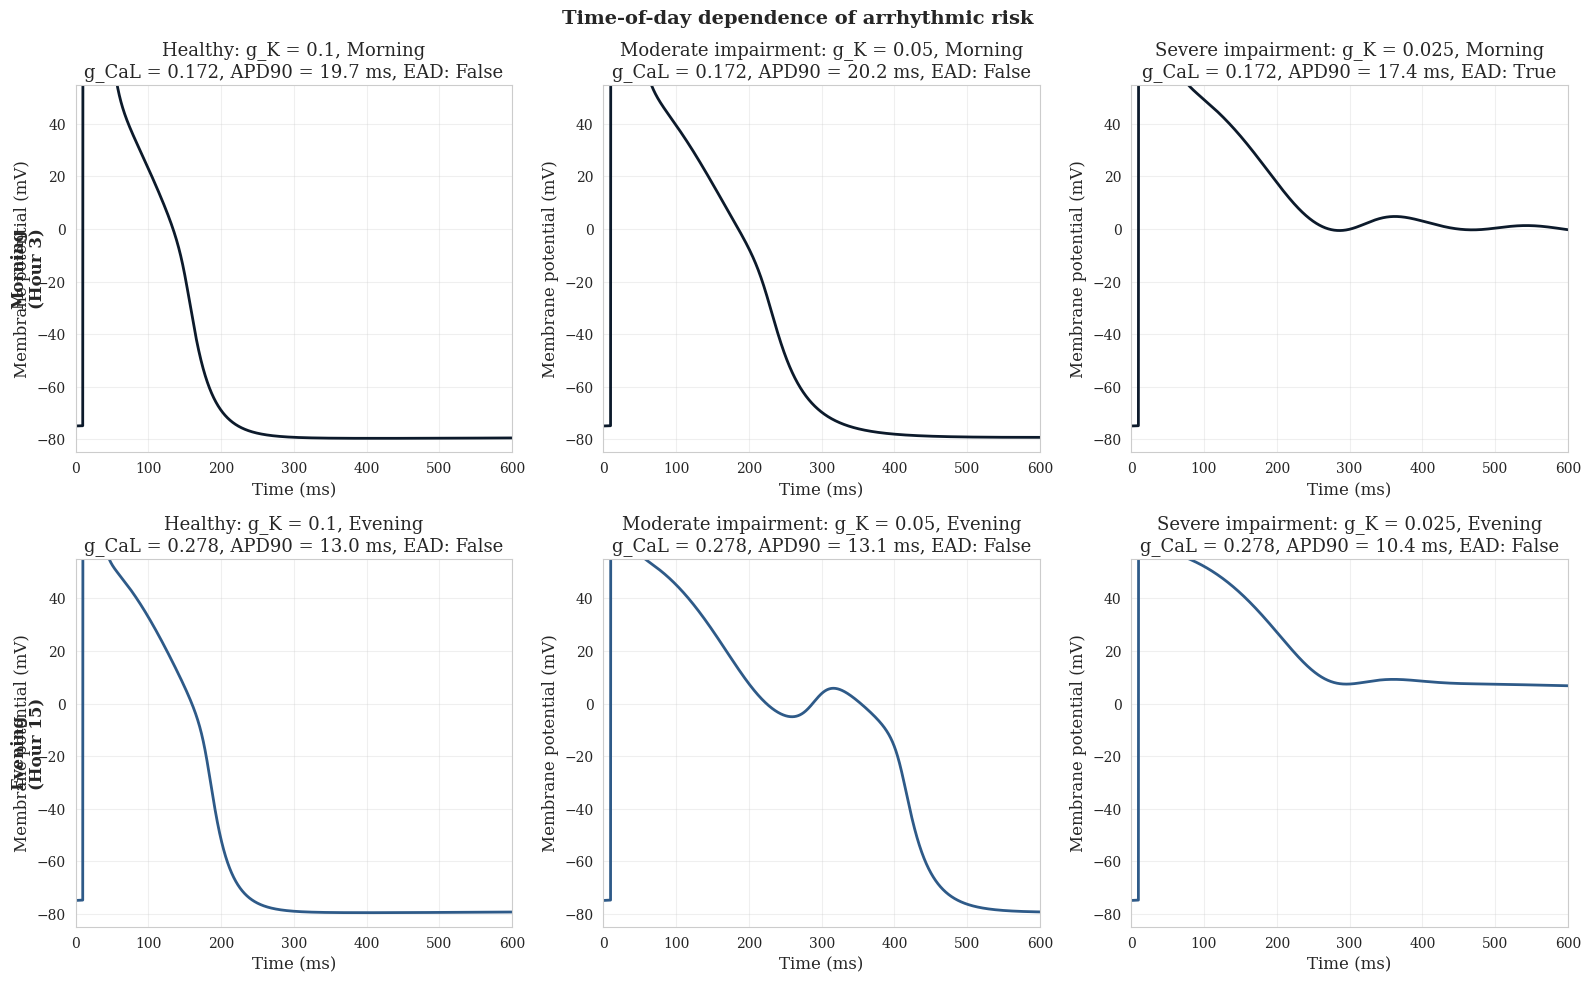


SUMMARY TABLE

----------------------------------------------------------------------
g_K      Time       g_CaL      APD90 (ms)   EAD   
----------------------------------------------------------------------
0.100    Morning    0.172      19.7         False 
0.100    Evening    0.278      13.0         False 
0.050    Morning    0.172      20.2         False 
0.050    Evening    0.278      13.1         False 
0.025    Morning    0.172      17.4         True  
0.025    Evening    0.278      10.4         False 
----------------------------------------------------------------------

ANALYSIS COMPLETE
Figures saved:
  - figure1_disease_progression.png
  - figure2_morning_evening_comparison.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import seaborn as sns

# Set seaborn style
sns.set_style("whitegrid")

# Times New Roman font
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif', 'Liberation Serif', 'serif'],
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 14
})

# Colour palette
COLORS = ['#0C1A2B', '#1B3A5C', '#2E5A88', '#4A7FB5', '#7BA3CC', '#A0A0A0', '#404040']


class CircadianArrhythmiaModel:
    """
    Modified Sato model for guinea pig ventricular myocyte with circadian
    modulation of L-type calcium conductance.

    Based on Diekman & Wei (2021), Biophysical Journal.
    """

    def __init__(self, g_K=0.1):
        # Membrane capacitance
        self.C = 1.0  # µF/cm²

        # Calcium current parameters
        self.g_CaL_base = 0.225  # mS/cm²
        self.A_CaL = 0.075       # mS/cm²
        self.E_Ca = 60           # mV
        self.theta_d = -7.3      # mV
        self.sigma_d = -8.6      # mV
        self.theta_f = -13.3     # mV
        self.sigma_f = 11.9      # mV
        self.tau_f = 80          # ms

        # Potassium current parameters
        self.g_K = g_K
        self.E_K = -80           # mV
        self.theta_x = -40       # mV
        self.sigma_x = -5        # mV
        self.tau_x = 300         # ms

        # Applied stimulus - STRENGTHENED to ensure AP firing
        self.stim_duration = 5   # ms
        self.stim_amplitude = 800  # µA/cm²
        self.stim_start = 10     # ms

    def circadian_g_CaL(self, t_hour):
        phase_shift = -np.pi/2
        return self.g_CaL_base + self.A_CaL * np.sin(2 * np.pi * t_hour / 24 + phase_shift)

    def d_inf(self, V):
        return 1.0 / (1.0 + np.exp((V - self.theta_d) / self.sigma_d))

    def f_inf(self, V):
        return 1.0 / (1.0 + np.exp((V - self.theta_f) / self.sigma_f))

    def x_inf(self, V):
        return 1.0 / (1.0 + np.exp((V - self.theta_x) / self.sigma_x))

    def I_stim(self, t):
        if self.stim_start <= t <= self.stim_start + self.stim_duration:
            return self.stim_amplitude
        return 0

    def system(self, t, y, t_hour):
        V, f, x = y
        g_CaL = self.circadian_g_CaL(t_hour)
        I_CaL = g_CaL * self.d_inf(V) * f * (V - self.E_Ca)
        I_K = self.g_K * x * (V - self.E_K)
        I_app = self.I_stim(t)
        dV_dt = (I_app - I_CaL - I_K) / self.C
        df_dt = (self.f_inf(V) - f) / self.tau_f
        dx_dt = (self.x_inf(V) - x) / self.tau_x
        return [dV_dt, df_dt, dx_dt]

    def simulate_action_potential(self, t_hour, duration=1000, y0=None):
        if y0 is None:
            V0 = -75  # More excitable
            f0 = 1.0  # Calcium channels fully available
            x0 = 0.0  # Potassium channels closed
            y0 = [V0, f0, x0]
        t_span = (0, duration)
        t_eval = np.linspace(0, duration, 5000)
        solution = solve_ivp(
            lambda t, y: self.system(t, y, t_hour),
            t_span, y0, method='RK45', t_eval=t_eval,
            rtol=1e-6, atol=1e-8
        )
        return solution.t, solution.y

    def detect_EADs(self, V, t, threshold=-20, min_peak_distance=50):
        from scipy.signal import find_peaks
        peak_idx = np.argmax(V)
        if peak_idx is None:
            return False
        V_repol = V[peak_idx:]
        if len(V_repol) < min_peak_distance:
            return False
        peaks, _ = find_peaks(V_repol, height=threshold, distance=min_peak_distance)
        return len(peaks) > 1

    def calculate_APD90(self, V, t):
        peak_idx = np.argmax(V)
        V_peak = V[peak_idx]
        V_rest = np.min(V[-100:])
        V_target = V_peak - 0.9 * (V_peak - V_rest)
        for i in range(peak_idx, len(V)):
            if V[i] <= V_target:
                return t[i] - t[peak_idx]
        return np.nan


def run_disease_progression():
    """Figure 1: Effect of reduced g_K on EAD emergence (morning condition)."""
    print("=" * 60)
    print("FIGURE 1: Risk of EADs increases with reduced g_K (morning)")
    print("=" * 60)

    conditions = [
        (0.1, COLORS[1], 'Healthy'),
        (0.05, COLORS[2], 'Moderate impairment'),
        (0.025, COLORS[0], 'Severe impairment')
    ]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    for ax, (g_K, color, label) in zip(axes, conditions):
        model = CircadianArrhythmiaModel(g_K=g_K)
        t, y = model.simulate_action_potential(3, duration=800)  # Hour 3 = morning
        V = y[0]
        g_CaL = model.circadian_g_CaL(3)
        apd90 = model.calculate_APD90(V, t)
        ead = model.detect_EADs(V, t)

        ax.plot(t, V, color=color, linewidth=2)
        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Membrane potential (mV)')
        apd_str = f"{apd90:.1f}" if not np.isnan(apd90) else "N/A"
        ax.set_title(f'{label}: g_K = {g_K}\nAPD90 = {apd_str} ms, EAD: {ead}')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 600)
        ax.set_ylim(-85, 55)

        print(f"\n{label} (g_K = {g_K}):")
        print(f"  g_CaL = {g_CaL:.3f} mS/cm²")
        print(f"  APD90 = {apd_str} ms")
        print(f"  EAD detected: {ead}")
        print(f"  Max V = {np.max(V):.1f} mV")

    plt.suptitle('Risk of EADs increases with reduced repolarisation reserve (morning)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('figure1_disease_progression.png', dpi=150, bbox_inches='tight')
    plt.show()

    return fig


def run_morning_vs_evening_comparison():
    """Figure 2: Time-of-day dependence of arrhythmic risk."""
    print("\n" + "=" * 60)
    print("FIGURE 2: Time-of-day dependence of arrhythmic risk")
    print("=" * 60)

    conditions = [
        (0.1, 'Healthy'),
        (0.05, 'Moderate impairment'),
        (0.025, 'Severe impairment')
    ]
    times = [(3, 'Morning'), (15, 'Evening')]

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))

    for i, (g_K, label) in enumerate(conditions):
        model = CircadianArrhythmiaModel(g_K=g_K)
        for j, (hour, time_name) in enumerate(times):
            ax = axes[j, i]
            t, y = model.simulate_action_potential(hour, duration=800)
            V = y[0]
            g_CaL = model.circadian_g_CaL(hour)
            apd90 = model.calculate_APD90(V, t)
            ead = model.detect_EADs(V, t)

            color = COLORS[0] if hour == 3 else COLORS[2]
            ax.plot(t, V, color=color, linewidth=2)
            ax.set_xlabel('Time (ms)')
            ax.set_ylabel('Membrane potential (mV)')
            apd_str = f"{apd90:.1f}" if not np.isnan(apd90) else "N/A"
            ax.set_title(f'{label}: g_K = {g_K}, {time_name}\ng_CaL = {g_CaL:.3f}, APD90 = {apd_str} ms, EAD: {ead}')
            ax.grid(True, alpha=0.3)
            ax.set_xlim(0, 600)
            ax.set_ylim(-85, 55)

            print(f"\n{label} (g_K = {g_K}), {time_name} (hour {hour}):")
            print(f"  g_CaL = {g_CaL:.3f} mS/cm²")
            print(f"  APD90 = {apd_str} ms")
            print(f"  EAD detected: {ead}")

    # Row labels
    axes[0, 0].text(-0.15, 0.5, 'Morning\n(Hour 3)', transform=axes[0, 0].transAxes,
                    fontsize=12, fontweight='bold', va='center', rotation=90)
    axes[1, 0].text(-0.15, 0.5, 'Evening\n(Hour 15)', transform=axes[1, 0].transAxes,
                    fontsize=12, fontweight='bold', va='center', rotation=90)

    plt.suptitle('Time-of-day dependence of arrhythmic risk',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('figure2_morning_evening_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    return fig


def generate_summary():
    """Print summary table of all conditions."""
    print("\n" + "=" * 60)
    print("SUMMARY TABLE")
    print("=" * 60)

    g_K_values = [0.1, 0.05, 0.025]
    hours = [3, 15]
    time_names = ['Morning', 'Evening']

    results = []

    for g_K in g_K_values:
        model = CircadianArrhythmiaModel(g_K=g_K)
        for hour, time_name in zip(hours, time_names):
            t, y = model.simulate_action_potential(hour, duration=800)
            V = y[0]
            g_CaL = model.circadian_g_CaL(hour)
            apd90 = model.calculate_APD90(V, t)
            ead = model.detect_EADs(V, t)

            results.append({
                'g_K': g_K,
                'Time': time_name,
                'g_CaL': g_CaL,
                'APD90': apd90,
                'EAD': ead
            })

    print("\n" + "-" * 70)
    print(f"{'g_K':<8} {'Time':<10} {'g_CaL':<10} {'APD90 (ms)':<12} {'EAD':<6}")
    print("-" * 70)

    for r in results:
        apd_str = f"{r['APD90']:.1f}" if not np.isnan(r['APD90']) else "N/A"
        print(f"{r['g_K']:<8.3f} {r['Time']:<10} {r['g_CaL']:<10.3f} {apd_str:<12} {str(r['EAD']):<6}")

    print("-" * 70)

    return results


if __name__ == "__main__":
    print("\n" + "♥ " * 30)
    print("CIRCADIAN ARRHYTHMIA MODEL")
    print("Time-of-day dependence of arrhythmic risk")
    print("Based on Diekman & Wei (2021), Biophysical Journal")
    print("♥ " * 30)

    fig1 = run_disease_progression()
    fig2 = run_morning_vs_evening_comparison()
    summary = generate_summary()

    print("\n" + "=" * 60)
    print("ANALYSIS COMPLETE")
    print("Figures saved:")
    print("  - figure1_disease_progression.png")
    print("  - figure2_morning_evening_comparison.png")
    print("=" * 60)